In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
 print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),std=(0.2470, 0.2435, 0.2616))])
train_dataset = datasets.CIFAR10( root="./data",train=True,download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data",train=False,download=True,transform=transform)

100%|██████████| 170M/170M [23:15<00:00, 122kB/s]


In [7]:
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)

In [8]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])


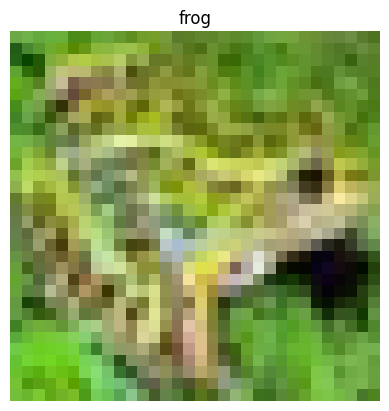

In [9]:
#to see the images
classes = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
image = images[0].cpu() * std + mean
image = torch.clamp(image, 0, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[labels[0]])
plt.axis("off");

In [10]:
#Because I am short on time but I am keen to do the project, I'm going to use a "minimum viable reproduction."
# So I'm deliberately using a small CNN because the model is not the research contribution
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(nn.Flatten(),nn.Linear(128 * 4 * 4, 256),nn.ReLU(),nn.Linear(256, 10))
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = SmallCNN().to(device)
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

In [14]:
#We're not training here.We're only asking:How good is our model on unseen test data?
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    loss = running_loss / total
    accuracy = correct / total
    return loss, accuracy

In [15]:
#I'll initially use 10 epochs.
EPOCHS = 10
history = {"train_loss": [],"train_acc": [],"test_loss": [],"test_acc": []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Train Acc: 0.4882 | Test Acc: 0.6067
Epoch 2/10 | Train Acc: 0.6564 | Test Acc: 0.6777
Epoch 3/10 | Train Acc: 0.7241 | Test Acc: 0.7205
Epoch 4/10 | Train Acc: 0.7712 | Test Acc: 0.7381
Epoch 5/10 | Train Acc: 0.8096 | Test Acc: 0.7565
Epoch 6/10 | Train Acc: 0.8363 | Test Acc: 0.7667
Epoch 7/10 | Train Acc: 0.8675 | Test Acc: 0.7703
Epoch 8/10 | Train Acc: 0.8935 | Test Acc: 0.7553
Epoch 9/10 | Train Acc: 0.9179 | Test Acc: 0.7710
Epoch 10/10 | Train Acc: 0.9377 | Test Acc: 0.7458


In [16]:
baseline_test_accuracy = history["test_acc"][-1]
print(f"Baseline test accuracy: "f"{baseline_test_accuracy * 100:.2f}%")

Baseline test accuracy: 74.58%


In [17]:
#Now comes the exciting part: Mixup
def mixup_data(images, labels, alpha=1.0):
    batch_size = images.size(0)
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(batch_size).to(images.device)
    mixed_images = (lam * images+ (1 - lam) * images[index])
    labels_a = labels
    labels_b = labels[index]
    return mixed_images, labels_a, labels_b, lam

In [18]:
def mixup_loss(criterion,predictions,labels_a,labels_b,lam):
    return (lam * criterion(predictions, labels_a)+ (1 - lam) * criterion(predictions, labels_b))

In [19]:
def train_one_epoch_mixup(model,loader,criterion,optimizer,device,alpha=1.0):
    model.train()
    running_loss = 0.0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        mixed_images, labels_a, labels_b, lam = mixup_data(images,labels,alpha)
        optimizer.zero_grad()
        outputs = model(mixed_images)
        loss = mixup_loss(criterion,outputs,labels_a,labels_b,lam)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total += images.size(0)
    epoch_loss = running_loss / total
    return epoch_loss

In [20]:
#Create a fresh model
mixup_model = SmallCNN().to(device)
mixup_optimizer = optim.Adam(mixup_model.parameters(),lr=0.001)

In [21]:
mixup_history = {"train_loss": [],"test_loss": [],"test_acc": []}
for epoch in range(EPOCHS):
    train_loss = train_one_epoch_mixup(mixup_model,train_loader,criterion,mixup_optimizer,device,alpha=1.0)
    test_loss, test_acc = evaluate(mixup_model,test_loader,criterion,device)
    mixup_history["train_loss"].append(train_loss)
    mixup_history["test_loss"].append(test_loss)
    mixup_history["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | "f"Test Acc: {test_acc:.4f}")

Epoch 1/10 | Test Acc: 0.5602
Epoch 2/10 | Test Acc: 0.6506
Epoch 3/10 | Test Acc: 0.6870
Epoch 4/10 | Test Acc: 0.7130
Epoch 5/10 | Test Acc: 0.7308
Epoch 6/10 | Test Acc: 0.7431
Epoch 7/10 | Test Acc: 0.7627
Epoch 8/10 | Test Acc: 0.7593
Epoch 9/10 | Test Acc: 0.7750
Epoch 10/10 | Test Acc: 0.7717


In [22]:
mixup_test_accuracy = mixup_history["test_acc"][-1]
print(f"Baseline: {baseline_test_accuracy * 100:.2f}%")
print(f"Mixup:    {mixup_test_accuracy * 100:.2f}%")

Baseline: 74.58%
Mixup:    77.17%


In [23]:
#Extension: Label Noise Robustness
def create_noisy_labels(labels, noise_rate, num_classes=10, seed=42):
    noisy_labels = labels.clone()
    generator = torch.Generator().manual_seed(seed)
    num_samples = len(labels)
    num_noisy = int(noise_rate * num_samples)
    # Randomly select which examples will receive noisy labels
    noisy_indices = torch.randperm(num_samples,generator=generator )[:num_noisy]
    random_labels = torch.randint(0,num_classes,(num_noisy,),generator=generator)
    # Make sure replacement labels are different
    original_labels = noisy_labels[noisy_indices]
    same = random_labels == original_labels
    while same.any():
        random_labels[same] = torch.randint(0,num_classes,(same.sum().item(),),generator=generator)
        same = random_labels == original_labels
    noisy_labels[noisy_indices] = random_labels
    return noisy_labels

In [24]:
#Let's test it with 20%
original_labels = torch.tensor(train_dataset.targets)
noisy_labels = create_noisy_labels(original_labels,noise_rate=0.20,num_classes=10,seed=42)

In [25]:
#Now let's verify how many labels changed:
num_changed = (original_labels != noisy_labels).sum().item()
print("Changed labels:", num_changed)
print("Noise rate:", num_changed / len(original_labels))

Changed labels: 10000
Noise rate: 0.2


In [26]:
for i in range(20):
    original = classes[original_labels[i]]
    noisy = classes[noisy_labels[i]]
    if original != noisy:
        print(f"Example {i}: "f"{original} → {noisy}" )

Example 6: bird → truck


In [27]:
# creat a noisy dataset
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, original_dataset, noisy_labels):
        self.dataset = original_dataset
        self.noisy_labels = noisy_labels
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, _ = self.dataset[index]

        label = self.noisy_labels[index]

        return image, label

In [28]:
noisy_train_dataset = NoisyCIFAR10(
    train_dataset,
    noisy_labels
)

In [29]:
noisy_train_loader = DataLoader(
    noisy_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [30]:
noisy_baseline_model = SmallCNN().to(device)

noisy_baseline_optimizer = optim.Adam(noisy_baseline_model.parameters(),lr=0.001)

In [31]:
noisy_baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

In [32]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        noisy_baseline_model,
        noisy_train_loader,
        criterion,
        noisy_baseline_optimizer,
        device
    )
    test_loss, test_acc = evaluate(
        noisy_baseline_model,
        test_loader,
        criterion,
        device
    )
    noisy_baseline_history["train_loss"].append(train_loss)
    noisy_baseline_history["train_acc"].append(train_acc)
    noisy_baseline_history["test_loss"].append(test_loss)
    noisy_baseline_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Train Acc: 0.3755 | Test Acc: 0.5676
Epoch 2/10 | Train Acc: 0.5038 | Test Acc: 0.6398
Epoch 3/10 | Train Acc: 0.5572 | Test Acc: 0.6784
Epoch 4/10 | Train Acc: 0.5934 | Test Acc: 0.7104
Epoch 5/10 | Train Acc: 0.6199 | Test Acc: 0.7070
Epoch 6/10 | Train Acc: 0.6476 | Test Acc: 0.6899
Epoch 7/10 | Train Acc: 0.6680 | Test Acc: 0.6958
Epoch 8/10 | Train Acc: 0.6981 | Test Acc: 0.6973
Epoch 9/10 | Train Acc: 0.7274 | Test Acc: 0.6689
Epoch 10/10 | Train Acc: 0.7572 | Test Acc: 0.6511


In [33]:
noisy_mixup_model = SmallCNN().to(device)
noisy_mixup_optimizer = optim.Adam(noisy_mixup_model.parameters(),lr=0.001)

In [34]:
noisy_mixup_history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

In [35]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch_mixup(
        noisy_mixup_model,
        noisy_train_loader,
        criterion,
        noisy_mixup_optimizer,
        device,
        alpha=1.0
    )
    test_loss, test_acc = evaluate(
        noisy_mixup_model,
        test_loader,
        criterion,
        device
    )
    noisy_mixup_history["train_loss"].append(train_loss)
    noisy_mixup_history["test_loss"].append(test_loss)
    noisy_mixup_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Test Acc: 0.5220
Epoch 2/10 | Test Acc: 0.6166
Epoch 3/10 | Test Acc: 0.6489
Epoch 4/10 | Test Acc: 0.6642
Epoch 5/10 | Test Acc: 0.6955
Epoch 6/10 | Test Acc: 0.7089
Epoch 7/10 | Test Acc: 0.7156
Epoch 8/10 | Test Acc: 0.7101
Epoch 9/10 | Test Acc: 0.7167
Epoch 10/10 | Test Acc: 0.7178


In [36]:
noisy_baseline_best = max(noisy_baseline_history["test_acc"])
noisy_mixup_best = max(noisy_mixup_history["test_acc"])
print(f"20% Noise - Standard: "f"{noisy_baseline_best * 100:.2f}%")
print(f"20% Noise - Mixup: "f"{noisy_mixup_best * 100:.2f}%")
difference = (noisy_mixup_best -noisy_baseline_best)
print(f"Mixup improvement: "f"{difference * 100:.2f} percentage points")

20% Noise - Standard: 71.04%
20% Noise - Mixup: 71.78%
Mixup improvement: 0.74 percentage points


In [38]:
# 10%
original_labels = torch.tensor(train_dataset.targets)
noisy_labels = create_noisy_labels(original_labels,noise_rate=0.10,num_classes=10,seed=42)

In [39]:
num_changed = (original_labels != noisy_labels).sum().item()
print("Changed labels:", num_changed)
print("Noise rate:", num_changed / len(original_labels))

Changed labels: 5000
Noise rate: 0.1


In [40]:
for i in range(20):
    original = classes[original_labels[i]]
    noisy = classes[noisy_labels[i]]
    if original != noisy:
        print(f"Example {i}: "f"{original} → {noisy}" )

Example 6: bird → truck


In [41]:
# creat a noisy dataset
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, original_dataset, noisy_labels):
        self.dataset = original_dataset
        self.noisy_labels = noisy_labels
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, _ = self.dataset[index]

        label = self.noisy_labels[index]

        return image, label

In [42]:
noisy_train_dataset = NoisyCIFAR10(
    train_dataset,
    noisy_labels
)

In [43]:
noisy_train_loader = DataLoader(
    noisy_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [44]:
noisy_baseline_model = SmallCNN().to(device)

noisy_baseline_optimizer = optim.Adam(noisy_baseline_model.parameters(),lr=0.001)

In [61]:
noisy_baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

In [63]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        noisy_baseline_model,
        noisy_train_loader,
        criterion,
        noisy_baseline_optimizer,
        device
    )
    test_loss, test_acc = evaluate(
        noisy_baseline_model,
        test_loader,
        criterion,
        device
    )
    noisy_baseline_history["train_loss"].append(train_loss)
    noisy_baseline_history["train_acc"].append(train_acc)
    noisy_baseline_history["test_loss"].append(test_loss)
    noisy_baseline_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Train Acc: 0.4429 | Test Acc: 0.6323
Epoch 2/10 | Train Acc: 0.4869 | Test Acc: 0.6685
Epoch 3/10 | Train Acc: 0.5174 | Test Acc: 0.6861
Epoch 4/10 | Train Acc: 0.5407 | Test Acc: 0.6770
Epoch 5/10 | Train Acc: 0.5674 | Test Acc: 0.6860
Epoch 6/10 | Train Acc: 0.5900 | Test Acc: 0.6661
Epoch 7/10 | Train Acc: 0.6211 | Test Acc: 0.6432
Epoch 8/10 | Train Acc: 0.6587 | Test Acc: 0.6303
Epoch 9/10 | Train Acc: 0.7025 | Test Acc: 0.5952
Epoch 10/10 | Train Acc: 0.7499 | Test Acc: 0.5763


In [64]:
noisy_mixup_model = SmallCNN().to(device)
noisy_mixup_optimizer = optim.Adam(noisy_mixup_model.parameters(),lr=0.001)

In [65]:
noisy_mixup_history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

In [66]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch_mixup(
        noisy_mixup_model,
        noisy_train_loader,
        criterion,
        noisy_mixup_optimizer,
        device,
        alpha=1.0
    )
    test_loss, test_acc = evaluate(
        noisy_mixup_model,
        test_loader,
        criterion,
        device
    )
    noisy_mixup_history["train_loss"].append(train_loss)
    noisy_mixup_history["test_loss"].append(test_loss)
    noisy_mixup_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Test Acc: 0.5009
Epoch 2/10 | Test Acc: 0.5448
Epoch 3/10 | Test Acc: 0.5958
Epoch 4/10 | Test Acc: 0.6590
Epoch 5/10 | Test Acc: 0.6475
Epoch 6/10 | Test Acc: 0.6749
Epoch 7/10 | Test Acc: 0.6779
Epoch 8/10 | Test Acc: 0.6923
Epoch 9/10 | Test Acc: 0.6798
Epoch 10/10 | Test Acc: 0.6960


In [69]:
noisy_baseline_best = max(noisy_baseline_history["test_acc"])
noisy_mixup_best = max(noisy_mixup_history["test_acc"])
print(f"10% Noise - Standard: "f"{noisy_baseline_best * 100:.2f}%")
print(f"10% Noise - Mixup: "f"{noisy_mixup_best * 100:.2f}%")
difference = (noisy_mixup_best -noisy_baseline_best)
print(f"Mixup improvement: "f"{difference * 100:.2f} percentage points")

10% Noise - Standard: 68.61%
10% Noise - Mixup: 69.60%
Mixup improvement: 0.99 percentage points


In [70]:
#30%
original_labels = torch.tensor(train_dataset.targets)
noisy_labels = create_noisy_labels(original_labels,noise_rate=0.30,num_classes=10,seed=42)

In [71]:
num_changed = (original_labels != noisy_labels).sum().item()
print("Changed labels:", num_changed)
print("Noise rate:", num_changed / len(original_labels))

Changed labels: 15000
Noise rate: 0.3


In [72]:
for i in range(20):
    original = classes[original_labels[i]]
    noisy = classes[noisy_labels[i]]
    if original != noisy:
        print(f"Example {i}: "f"{original} → {noisy}" )

Example 6: bird → truck
Example 8: ship → truck
Example 12: horse → cat
Example 17: cat → frog


In [73]:
# creat a noisy dataset
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, original_dataset, noisy_labels):
        self.dataset = original_dataset
        self.noisy_labels = noisy_labels
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, _ = self.dataset[index]

        label = self.noisy_labels[index]

        return image, label

In [74]:
noisy_train_dataset = NoisyCIFAR10(
    train_dataset,
    noisy_labels
)

In [75]:
noisy_train_loader = DataLoader(
    noisy_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [76]:
noisy_baseline_model = SmallCNN().to(device)

noisy_baseline_optimizer = optim.Adam(noisy_baseline_model.parameters(),lr=0.001)

In [77]:
noisy_baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

In [78]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        noisy_baseline_model,
        noisy_train_loader,
        criterion,
        noisy_baseline_optimizer,
        device
    )
    test_loss, test_acc = evaluate(
        noisy_baseline_model,
        test_loader,
        criterion,
        device
    )
    noisy_baseline_history["train_loss"].append(train_loss)
    noisy_baseline_history["train_acc"].append(train_acc)
    noisy_baseline_history["test_loss"].append(test_loss)
    noisy_baseline_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Train Acc: 0.3244 | Test Acc: 0.5468
Epoch 2/10 | Train Acc: 0.4355 | Test Acc: 0.6148
Epoch 3/10 | Train Acc: 0.4815 | Test Acc: 0.6650
Epoch 4/10 | Train Acc: 0.5148 | Test Acc: 0.6715
Epoch 5/10 | Train Acc: 0.5398 | Test Acc: 0.6791
Epoch 6/10 | Train Acc: 0.5637 | Test Acc: 0.6954
Epoch 7/10 | Train Acc: 0.5844 | Test Acc: 0.6772
Epoch 8/10 | Train Acc: 0.6127 | Test Acc: 0.6504
Epoch 9/10 | Train Acc: 0.6472 | Test Acc: 0.6339
Epoch 10/10 | Train Acc: 0.6802 | Test Acc: 0.6085


In [79]:
noisy_mixup_model = SmallCNN().to(device)
noisy_mixup_optimizer = optim.Adam(noisy_mixup_model.parameters(),lr=0.001)

In [80]:
noisy_mixup_history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

In [81]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch_mixup(
        noisy_mixup_model,
        noisy_train_loader,
        criterion,
        noisy_mixup_optimizer,
        device,
        alpha=1.0
    )
    test_loss, test_acc = evaluate(
        noisy_mixup_model,
        test_loader,
        criterion,
        device
    )
    noisy_mixup_history["train_loss"].append(train_loss)
    noisy_mixup_history["test_loss"].append(test_loss)
    noisy_mixup_history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/10 | Test Acc: 0.5034
Epoch 2/10 | Test Acc: 0.5830
Epoch 3/10 | Test Acc: 0.6090
Epoch 4/10 | Test Acc: 0.6581
Epoch 5/10 | Test Acc: 0.6855
Epoch 6/10 | Test Acc: 0.6835
Epoch 7/10 | Test Acc: 0.6647
Epoch 8/10 | Test Acc: 0.6939
Epoch 9/10 | Test Acc: 0.6949
Epoch 10/10 | Test Acc: 0.6761


In [82]:
noisy_baseline_best = max(noisy_baseline_history["test_acc"])
noisy_mixup_best = max(noisy_mixup_history["test_acc"])
print(f"30% Noise - Standard: "f"{noisy_baseline_best * 100:.2f}%")
print(f"30% Noise - Mixup: "f"{noisy_mixup_best * 100:.2f}%")
difference = (noisy_mixup_best -noisy_baseline_best)
print(f"Mixup improvement: "f"{difference * 100:.2f} percentage points")

30% Noise - Standard: 69.54%
30% Noise - Mixup: 69.49%
Mixup improvement: -0.05 percentage points


Mixup advantages:
0% noise: +2.59 percentage points
10% noise: +0.99 percentage points
20% noise: +0.74 percentage points
30% noise: -0.05 percentage points


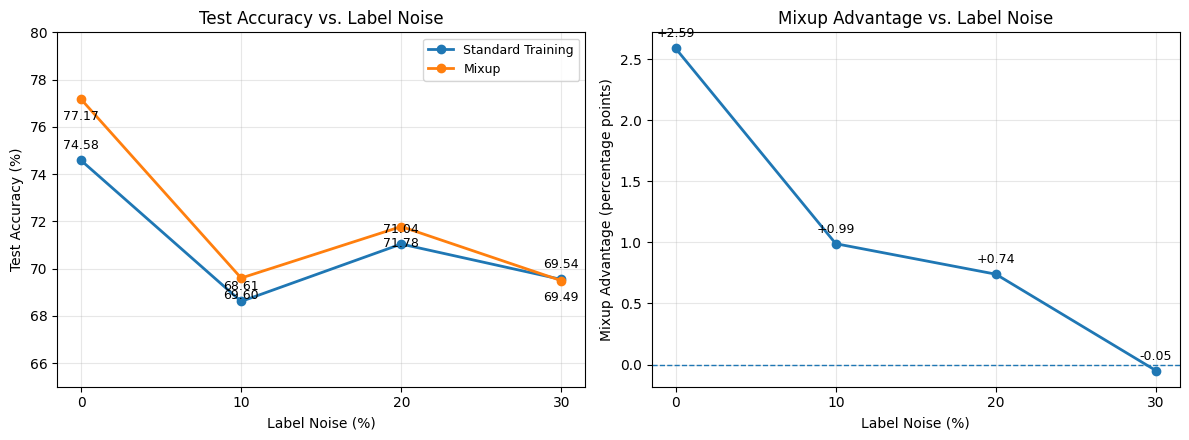


FINAL EXPERIMENTAL RESULTS
Noise       Standard       Mixup          Advantage      
------------------------------------------------------------
0%          74.58%          77.17%          +2.59 pp
10%          68.61%          69.60%          +0.99 pp
20%          71.04%          71.78%          +0.74 pp
30%          69.54%          69.49%          -0.05 pp


In [85]:
import matplotlib.pyplot as plt

noise_levels = [0, 10, 20, 30]

baseline_acc = [74.58,68.61,71.04,69.54]
mixup_acc = [77.17,69.60,71.78,69.49]
mixup_advantage = [mixup - baseline for mixup, baseline in zip(mixup_acc, baseline_acc)]
print("Mixup advantages:")
for noise, advantage in zip(noise_levels, mixup_advantage):
    print(f"{noise}% noise: {advantage:+.2f} percentage points")
fig, axes = plt.subplots(1, 2,figsize=(12, 4.5))
ax1 = axes[0]
ax1.plot(
    noise_levels,
    baseline_acc,
    marker='o',
    linewidth=2,
    markersize=6,
    label='Standard Training'
)

ax1.plot(
    noise_levels,
    mixup_acc,
    marker='o',
    linewidth=2,
    markersize=6,
    label='Mixup'
)

# Accuracy labels
for x, y in zip(noise_levels, baseline_acc):
    ax1.annotate(
        f'{y:.2f}',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

for x, y in zip(noise_levels, mixup_acc):
    ax1.annotate(
        f'{y:.2f}',
        (x, y),
        xytext=(0, -15),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax1.set_title(
    'Test Accuracy vs. Label Noise',
    fontsize=12
)

ax1.set_xlabel(
    'Label Noise (%)',
    fontsize=10
)

ax1.set_ylabel(
    'Test Accuracy (%)',
    fontsize=10
)

ax1.set_xticks(noise_levels)

ax1.set_ylim(65, 80)

ax1.grid(
    True,
    alpha=0.3
)

ax1.legend(
    fontsize=9
)

ax2 = axes[1]

ax2.plot(
    noise_levels,
    mixup_advantage,
    marker='o',
    linewidth=2,
    markersize=6
)

# Zero reference line
ax2.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

# Advantage labels
for x, y in zip(noise_levels, mixup_advantage):
    ax2.annotate(
        f'{y:+.2f}',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax2.set_title(
    'Mixup Advantage vs. Label Noise',
    fontsize=12
)

ax2.set_xlabel(
    'Label Noise (%)',
    fontsize=10
)

ax2.set_ylabel(
    'Mixup Advantage (percentage points)',
    fontsize=10
)

ax2.set_xticks(noise_levels)

ax2.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()
print("\n" + "=" * 60)
print("FINAL EXPERIMENTAL RESULTS")
print("=" * 60)

print(
    f"{'Noise':<12}"
    f"{'Standard':<15}"
    f"{'Mixup':<15}"
    f"{'Advantage':<15}"
)

print("-" * 60)

for noise, baseline, mixup, advantage in zip(
    noise_levels,
    baseline_acc,
    mixup_acc,
    mixup_advantage
):

    print(
        f"{noise}%"
        f"{baseline:>15.2f}%"
        f"{mixup:>15.2f}%"
        f"{advantage:>+15.2f} pp"
    )

print("=" * 60)